# Paso 1 — Decisión de granularidad del target (GRD)

**Pregunta a resolver:** ¿predecimos los 526 GRDs directos, o agregamos a un nivel más grueso?

Esta decisión condiciona todo el resto del pipeline (preprocesamiento, métricas, arquitectura).

**Estructura del código IR-GRD (6 dígitos)** — formato `AAA BB S`:
- `AAA` = Categoría Diagnóstica Mayor (CDM) + GRD base dentro de la CDM
- `BB`  = subtipo del GRD
- `S`   = severidad (1 = sin CC, 2 = con CC, 3 = con MCC)

Adicionalmente cada GRD viene prefijado con `PH` (Procedural Hierarchy / quirúrgico) o `MH` (Medical Hierarchy / médico).

Niveles de agregación que vamos a evaluar:
1. **GRD completo** (526 clases) — máxima resolución.
2. **GRD base** (sin severidad, primeros 5 dígitos) — colapsa W/CC y W/MCC.
3. **CDM + base** (primeros 3 dígitos) — colapsa subtipos.
4. **CDM** (primeros 2 dígitos) — máxima agregación clínica útil.
5. **Tipo PH/MH** (binario) — sanity check, baseline trivial.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)

DATA = Path('../data/dataset_elpino.csv')
OUT  = Path('.')
df = pd.read_csv(DATA, sep=None, engine='python')
print(f'Filas: {len(df):,} | Columnas: {len(df.columns)}')

Filas: 14,561 | Columnas: 68


## 1. Descomponer el código GRD

In [2]:
# El campo GRD viene como 'CODIGO - DESCRIPCION'
# Ej: '146101 - PH CESAREA'
ej = df['GRD'].iloc[0]
print('Ejemplo:', ej)

def parsear_grd(texto):
    if pd.isna(texto):
        return pd.Series([None]*5)
    partes = texto.split(' - ', 1)
    codigo = partes[0].strip()
    desc   = partes[1].strip() if len(partes) > 1 else ''
    tipo   = desc[:2] if desc[:2] in ('PH','MH') else 'OT'
    return pd.Series([
        codigo,         # 146101
        codigo[:5],     # 14610 — GRD base (sin severidad)
        codigo[:3],     # 146   — CDM + base
        codigo[:2],     # 14    — CDM
        tipo,           # PH / MH
    ])

df[['grd_full','grd_base','grd_cdm_base','cdm','tipo_phmh']] = df['GRD'].apply(parsear_grd)
df[['GRD','grd_full','grd_base','grd_cdm_base','cdm','tipo_phmh']].head(5)

Ejemplo: 184103 - MH SEPTICEMIA W/MCC


,GRD,grd_full,grd_base,grd_cdm_base,cdm,tipo_phmh
0,184103 - MH SEPTICEMIA W/MCC,184103,18410,184,18,MH
1,041013 - PH ECMO VENTILACIÓN MECÁNICA PROLONGADA CON TRAQUEOSTOMÍA W/MCC,041013,04101,041,04,PH
2,041013 - PH ECMO VENTILACIÓN MECÁNICA PROLONGADA CON TRAQUEOSTOMÍA W/MCC,041013,04101,041,04,PH
3,041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SIN TRAQUEOSTOMÍA W/MCC,041023,04102,041,04,PH
4,041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SIN TRAQUEOSTOMÍA W/MCC,041023,04102,041,04,PH


## 2. Cantidad de clases en cada nivel

In [3]:
niveles = ['grd_full','grd_base','grd_cdm_base','cdm','tipo_phmh']
resumen = pd.DataFrame({
    'nivel': niveles,
    'n_clases': [df[n].nunique() for n in niveles],
})
resumen

,nivel,n_clases
0,grd_full,526
1,grd_base,210
2,grd_cdm_base,37
3,cdm,22
4,tipo_phmh,2


## 3. Distribución y desbalance por nivel

Indicadores clave:
- **n_singletons** = clases con un solo paciente (no permiten estratificar).
- **n_<5** = clases con menos de 5 ejemplos (problemáticas).
- **clases_para_80pct** = mínimo de clases que cubren el 80% de los pacientes (cuán pesada es la cola).
- **gini** = índice de desigualdad sobre las frecuencias (0 = uniforme, 1 = todo en una clase).

In [4]:
def gini(x):
    x = np.sort(np.asarray(x, dtype=float))
    n = len(x)
    if n == 0 or x.sum() == 0:
        return 0.0
    return (2*np.arange(1,n+1)*x).sum() / (n*x.sum()) - (n+1)/n

filas = []
for n in niveles:
    counts = df[n].value_counts()
    acum = counts.cumsum() / counts.sum()
    k80  = int((acum < 0.80).sum() + 1)
    filas.append({
        'nivel': n,
        'n_clases': len(counts),
        'mediana_pac/clase': int(counts.median()),
        'min': int(counts.min()),
        'max': int(counts.max()),
        'singletons': int((counts == 1).sum()),
        'clases_<5': int((counts < 5).sum()),
        'clases_para_80pct': k80,
        'gini': round(gini(counts.values), 3),
    })
tabla = pd.DataFrame(filas)
tabla

,nivel,n_clases,mediana_pac/clase,min,max,singletons,clases_<5,clases_para_80pct,gini
0,grd_full,526,8,1,813,76,199,119,0.733
1,grd_base,210,19,1,1220,21,45,49,0.727
2,grd_cdm_base,37,213,1,2934,1,3,13,0.617
3,cdm,22,305,13,2934,0,0,9,0.568
4,tipo_phmh,2,7280,6704,7857,0,0,2,0.040


## 4. Curva de cobertura acumulada

Para cada nivel: ¿qué % de pacientes cubrimos si nos quedamos con las K clases más frecuentes?

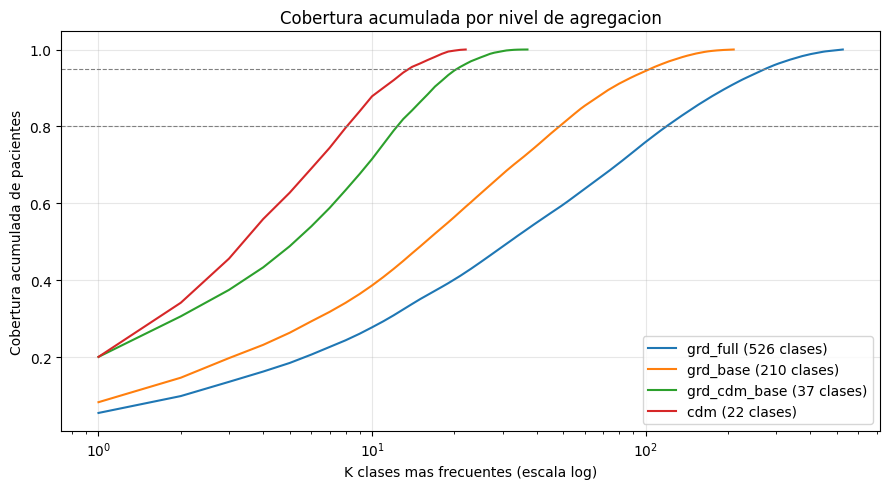

In [5]:
fig, ax = plt.subplots(figsize=(9,5))
for n in ['grd_full','grd_base','grd_cdm_base','cdm']:
    counts = df[n].value_counts().values
    cob = np.cumsum(counts) / counts.sum()
    ax.plot(np.arange(1, len(cob)+1), cob, label=f'{n} ({len(cob)} clases)')
ax.axhline(0.80, ls='--', c='gray', lw=0.8)
ax.axhline(0.95, ls='--', c='gray', lw=0.8)
ax.set_xscale('log')
ax.set_xlabel('K clases mas frecuentes (escala log)')
ax.set_ylabel('Cobertura acumulada de pacientes')
ax.set_title('Cobertura acumulada por nivel de agregacion')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT/'cobertura_por_nivel.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Tipo PH vs MH (sanity check)

In [6]:
print('Distribucion PH vs MH:')
print(df['tipo_phmh'].value_counts())
print()
print('Si predijeramos solo la clase mayoritaria, accuracy =',
      round(df['tipo_phmh'].value_counts(normalize=True).max(), 3))

Distribucion PH vs MH:
tipo_phmh
MH    7857
PH    6704
Name: count, dtype: int64

Si predijeramos solo la clase mayoritaria, accuracy = 0.54


## 6. Estrategia propuesta — *long-tail*

Una alternativa intermedia es **mantener GRD completo para clases con suficientes ejemplos y agrupar el resto en `OTROS`**. Evaluamos varios umbrales para ver cuántas clases nos quedan y cuántos pacientes terminan en `OTROS`.

In [7]:
umbrales = [5, 10, 20, 30, 50, 100]
counts_full = df['grd_full'].value_counts()
tot = len(df)

filas = []
for u in umbrales:
    clases_validas = counts_full[counts_full >= u].index
    n_clases = len(clases_validas) + 1  # +1 por OTROS
    n_otros  = (~df['grd_full'].isin(clases_validas)).sum()
    filas.append({
        'umbral_min_pacientes': u,
        'n_clases_resultantes': n_clases,
        'pacientes_en_OTROS': n_otros,
        '%_en_OTROS': round(100*n_otros/tot, 2),
    })
pd.DataFrame(filas)

,umbral_min_pacientes,n_clases_resultantes,pacientes_en_OTROS,%_en_OTROS
0,5,328,426,2.93
1,10,230,1107,7.60
2,20,153,2161,14.84
3,30,114,3081,21.16
4,50,70,4805,33.00
5,100,34,7151,49.11


## 7. Conclusion y decision

_Completar despues de revisar las tablas de arriba._ Plantilla de decisión:

- **Si `clases_para_80pct` en `grd_full` es muy alto y `singletons` > 100** → no es razonable predecir 526 clases; conviene agrupar.
- **Si CDM (~25-30 clases) tiene Gini moderado** → es un buen target principal del paper.
- **Estrategia recomendada por defecto**: predecir a **dos niveles** y reportar ambos:
  1. *Target principal:* CDM o GRD_base (manejable, métricas estables).
  2. *Target secundario:* GRD completo con umbral de agrupacion `>= 20` pacientes (resto a `OTROS`).

Esto cumple el enunciado (el GRD del enunciado es la salida) y al mismo tiempo permite reportar resultados solidos.